In [13]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator

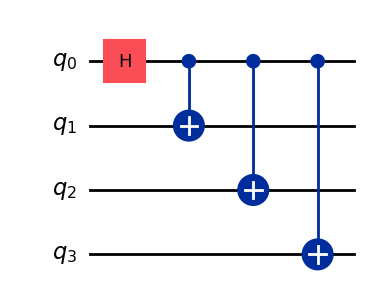

In [14]:
# Create a new circuit with two qubits
qc = QuantumCircuit(4)

# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)
qc.cx(0, 2)
qc.cx(0, 3)

# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")

In [15]:
# Set up six different observables.


observables = [SparsePauliOp("ZIZZ")]

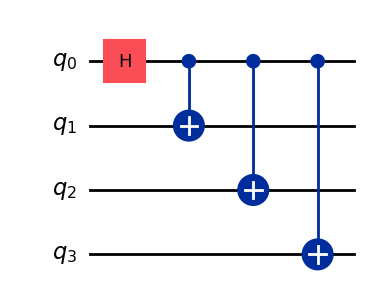

In [16]:
backend = AerSimulator(method="statevector")

# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
isa_circuit.draw("mpl")

In [17]:
from qiskit_ibm_runtime.options.utils import UnsetType
from qiskit_ibm_runtime import EstimatorOptions

# Run:
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
my_options = EstimatorOptions()
# Turn off all error mitigation and suppression
# my_options.resilience_level = 0
# my_options.default_shots = 420
my_options.default_precision = 0.1
# my_options.seed_estimator = 42
# my_options.simulator.seed_simulator = 42
# print(my_options)
# my_options.options.environment.log_level = "DEBUG"
# QISKIT_IBM_RUNTIME_LOG_LEVEL = "DEBUG"
# QISKIT_IBM_RUNTIME_LOG_FILE = "LOGGER.txt"
estimator = Estimator(backend, options=my_options)

from qiskit.primitives import StatevectorEstimator
if isinstance(my_options.default_precision, UnsetType):
    precision = 0.0
else:
    precision = my_options.default_precision
# if isinstance(my_options.simulator.seed_simulator, UnsetType):
#     seed = None
# else:
#     seed = my_options.simulator.seed_simulator
estimator = StatevectorEstimator(default_precision=precision)
# mapped_observables = observables
# isa_circuit = qc

values = []
for _ in range(1000):
    pubs = [(isa_circuit, mapped_observables)]


    job = estimator.run(pubs)

    for pub_result in job.result():
        values.append(pub_result.data.evs[0])
print(values)

[np.float64(-0.046423659741358814), np.float64(0.29365616781402026), np.float64(0.13641621706944507), np.float64(0.024663183740288527), np.float64(0.0009278586598599139), np.float64(-0.166182525845754), np.float64(-0.15533781006724556), np.float64(-0.1621241078507477), np.float64(0.06953653086571887), np.float64(-0.0796197233326377), np.float64(-0.11191346986722411), np.float64(0.007093721431376657), np.float64(-0.01761613182882071), np.float64(0.010091193942223626), np.float64(0.12720289280230235), np.float64(0.20432235758366102), np.float64(0.031968540723324966), np.float64(-0.05314234900447498), np.float64(0.17866980111700695), np.float64(0.06700486767792753), np.float64(0.04284306005490302), np.float64(0.09022823284981792), np.float64(0.15415393626793072), np.float64(0.016194071879452508), np.float64(-0.1128111686496002), np.float64(-0.0787584073720199), np.float64(0.03860442897843202), np.float64(0.10589420484205117), np.float64(-0.08423490313243832), np.float64(-0.129468246414483

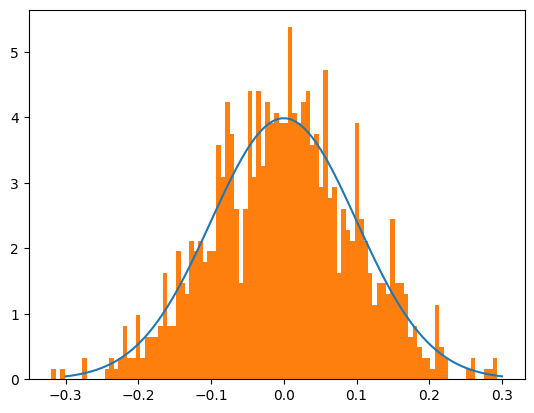

In [18]:
# This is the result from our single pub, which had six observables,
# so contains information on all six.
import scipy.stats as stats


mu = 0
variance = my_options.default_precision**2
sigma = np.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.hist(values, density=True, bins=100)
plt.show()

These discrete peaks are due to the following effect:
- The only physically possible measurements are -1 and +1.
- For a given precision $p$ the estimator takes $\sim \frac{1}{p^2}$ shots from -1 and +1.
- The values can only combine to discrete values for a small amount of shots.